In [242]:
from matplotlib import pyplot as plt
import numpy as np

In [243]:
try:
    import keras
    import tensorflow
except:
    !pip install keras_preprocessing
    !pip install keras
    !pip install tensorflow
    import keras
    import tensorflow

In [244]:
import keras
import tensorflow

In [245]:
from keras_preprocessing import image as img

In [246]:
from PIL import Image

In [247]:
from keras.preprocessing.image import img_to_array

In [248]:
#K = np.array([[-1,-2,-1],[0,0,0],[1,2,1]])
#M = np.array([[1,2,3,4],[4,5,6,4],[7,8,9,4],[3,6,0,1]])

M = np.array([[1,2,3],[4,5,6],[7,8,9]])
K = np.array([[1,2],[3,4]])


In [249]:
path = "./Monalisa.webp"
image =plt.imread(path)

In [250]:
sizt = 4
imga = img.load_img(
    path,
    target_size=(sizt,sizt),
    color_mode="grayscale",

)

In [251]:
image = imga.resize([sizt, sizt])



In [252]:
image

In [253]:
#IMAG = img_to_array(image).reshape(sizt,sizt)
IMAG = M

In [254]:
IMAG.shape

(3, 3)

In [255]:
K.shape

(2, 2)

In [256]:
"IMAG = M"

'IMAG = M'

In [257]:
#print(img.ima_to_array(image))

In [258]:
K,M

(array([[1, 2],
        [3, 4]]),
 array([[1, 2, 3],
        [4, 5, 6],
        [7, 8, 9]]))

In [259]:
def flatten_kernel(K):
    ''''Esta função realizará as devidas conversões para transformar uma convolução em multiplicação de matrizes ela será aplicada somente no kernel'''

    size = K.shape[0]
    outK = np.zeros((1,size**2))
    k = 0
    for i in range (size):
        for j in range(size):
        
            outK[0][k] = K[i][j]
            k+=1
    return outK

In [260]:
def inv_transform(M,sizeMinicial):
    "Inversão das transformações"
    size = int(np.sqrt(2*sizeMinicial-1))
    Mout = np.zeros((size,size))
    print(size)

    k = 0
    for i in range(size):
        for j in range(size):
            Mout[i][j] = M[k][0]
            print(M[k][0],M[0][k])
            k+=1

    return Mout

In [261]:
def transform_matrix(M,Kern):
    ''''Esta função realizará as devidas conversões para transformar uma convolução em multiplicação de matrizes ela será aplicada matriz de entra'''
    sizeKernel  = Kern.shape[0] 
    size = M.shape[0]
    Mout = np.zeros((int((size-1)**2),sizeKernel**2))
    print(Mout.shape[0])
    k = 0
    for i in range(0,sizeKernel):
        for j in range(0,sizeKernel):

            #X0 ,X1 ,X2 ,X3 ,X4 ,X5 ,X6 ,X7 ,X8 = M[i][j],M[i][j+1],M[i][j+2],M[i+1][j+0],M[i+1][j+1],M[i+1][j+2],M[i+2][j+0],M[i+2][j+1],M[i+2][j+2]
            #Mout[k+0][0+0] = X0
            #Mout[k+0][0+1] = X1
            #Mout[k+0][0+2] = X2
            #Mout[k+0][0+3] = X3
            #Mout[k+0][0+4] = X4
            #Mout[k+0][0+5] = X5
            #Mout[k+0][0+6] = X6
            #Mout[k+0][0+7] = X7
            #Mout[k+0][0+8] = X8

            X0 ,X1 ,X2 ,X3 = M[i][j],M[i][j+1],M[i+1][j],M[i+1][j+1]
            Mout[k+0][0+0] = X0
            Mout[k+0][0+1] = X1
            Mout[k+0][0+2] = X2
            Mout[k+0][0+3] = X3

            k+=1

    return Mout


In [262]:
def normalizeMatrixSIZE(matrix,sizeTarget):
    matrixMout = np.zeros((sizeTarget,sizeTarget))
    size_row = matrix.shape[1]
    size_lin = matrix.shape[0]
    for i in range(size_lin):
        for j in  range(size_row):
            matrixMout[i][j] = matrix[i][j]
            #print("Aqui",matrix[i][j])
    return matrixMout
    


In [263]:
def conv2mult(sizeTarget, inputConv,inputK):
    '''Esta função realizá as transformações necessárias para converter a operação de convolução em uma multiplicação de matrizes'''
    Matrix_tranform = transform_matrix(inputConv,inputK)
    Kernel_transform = flatten_kernel(inputK)
    matrix_target_image=normalizeMatrixSIZE(matrix=Matrix_tranform,sizeTarget =Matrix_tranform.shape[0])
    matrix_target_kernel=normalizeMatrixSIZE(matrix=Kernel_transform,sizeTarget=Matrix_tranform.shape[0])
    return (matrix_target_kernel,matrix_target_image)

In [264]:
A,B = conv2mult(sizeTarget=16,inputConv=IMAG,inputK=K)

4


In [265]:
Mout_vec = A@B

In [266]:
Mout_vec

array([[37., 47., 67., 77.],
       [ 0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.]])

In [267]:
Mout = inv_transform(Mout_vec,sizeMinicial = IMAG.shape[0])

1
37.0 37.0


In [268]:
print(Mout)

[[37.]]


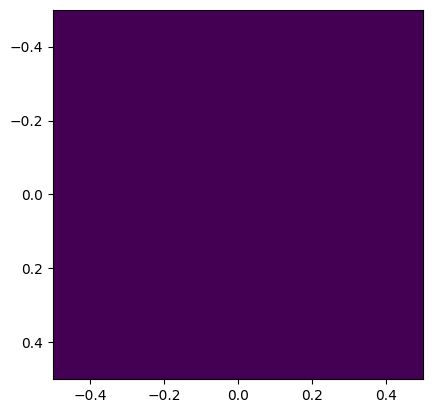

In [269]:
plt.imshow(Mout)